In [98]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv('T_F41SCHEDULE_B43.csv', dtype={'AIRCRAFT_TYPE': str})

<Axes: >

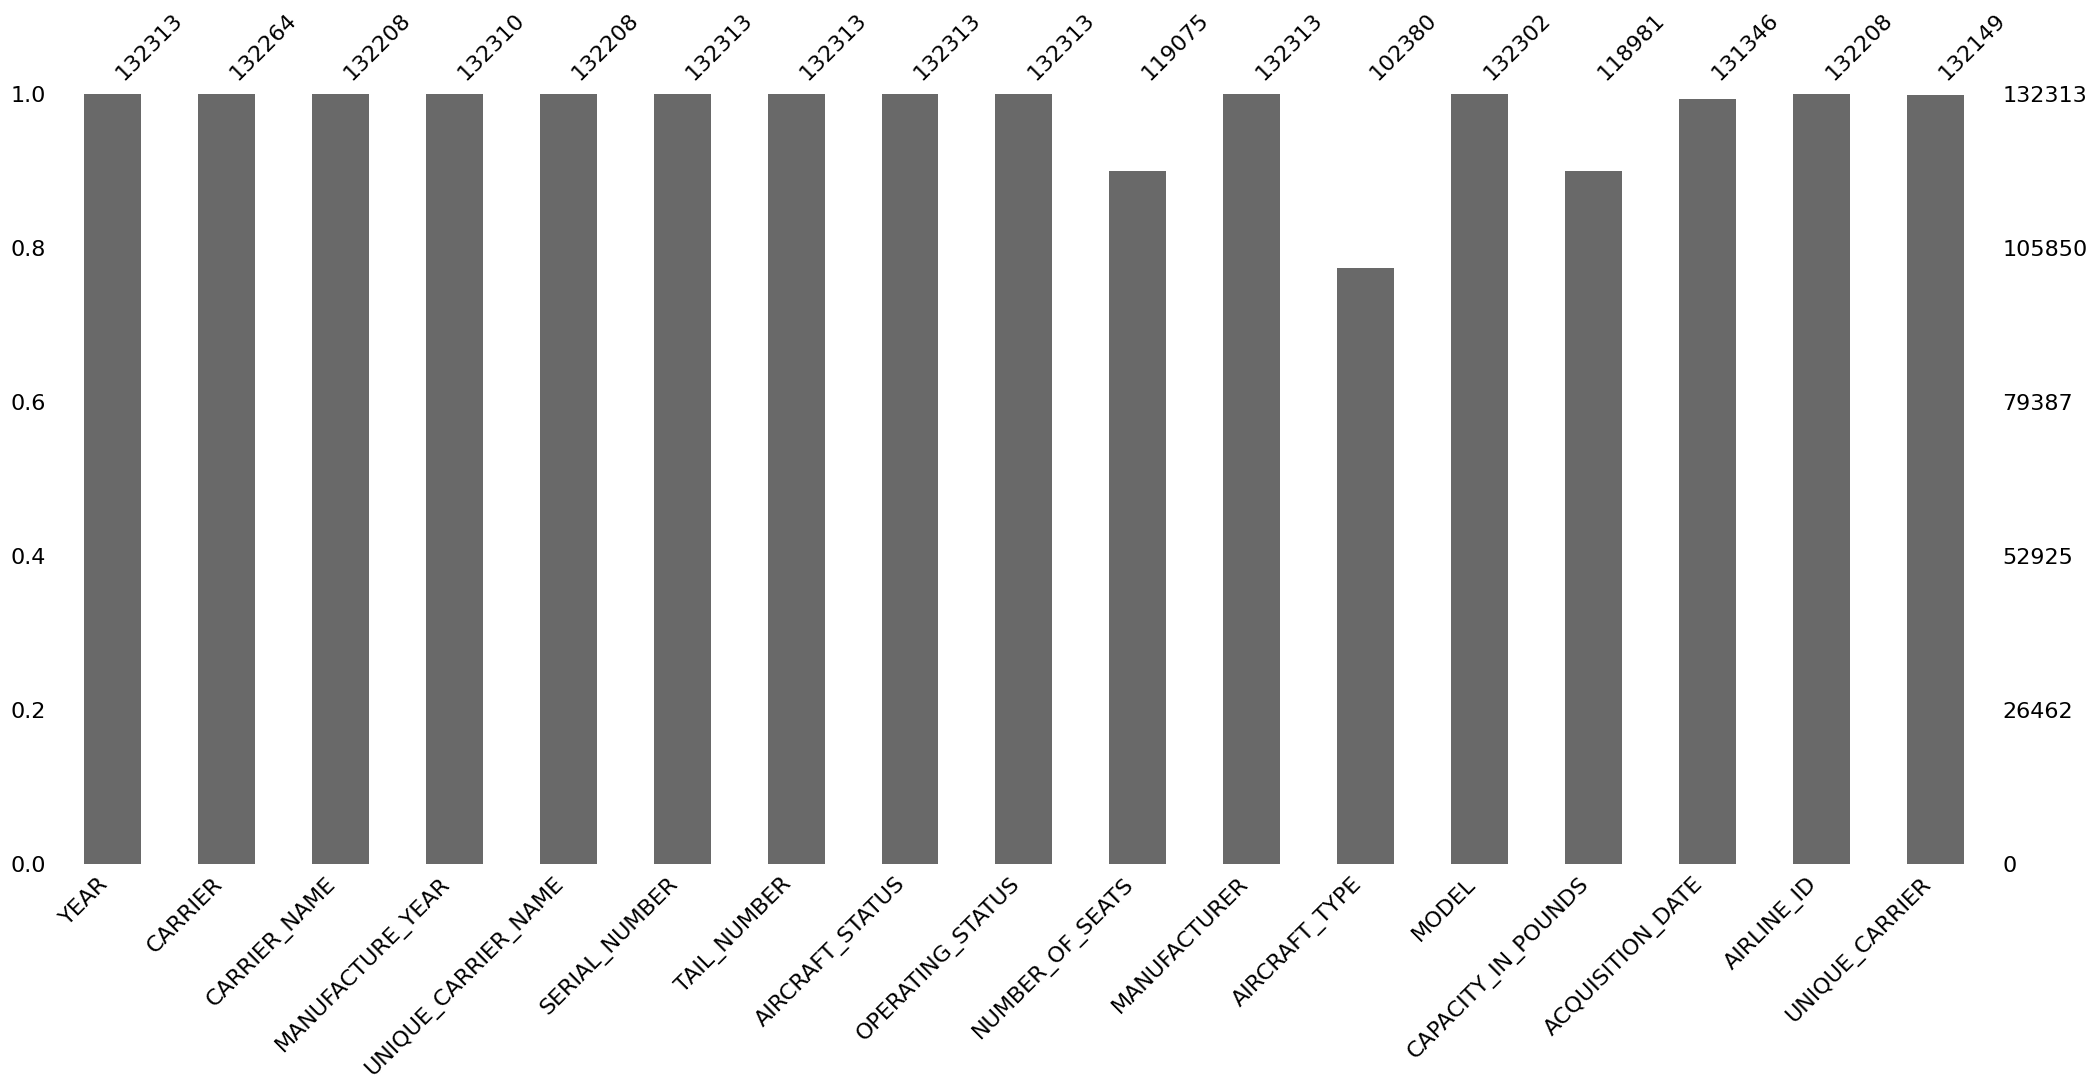

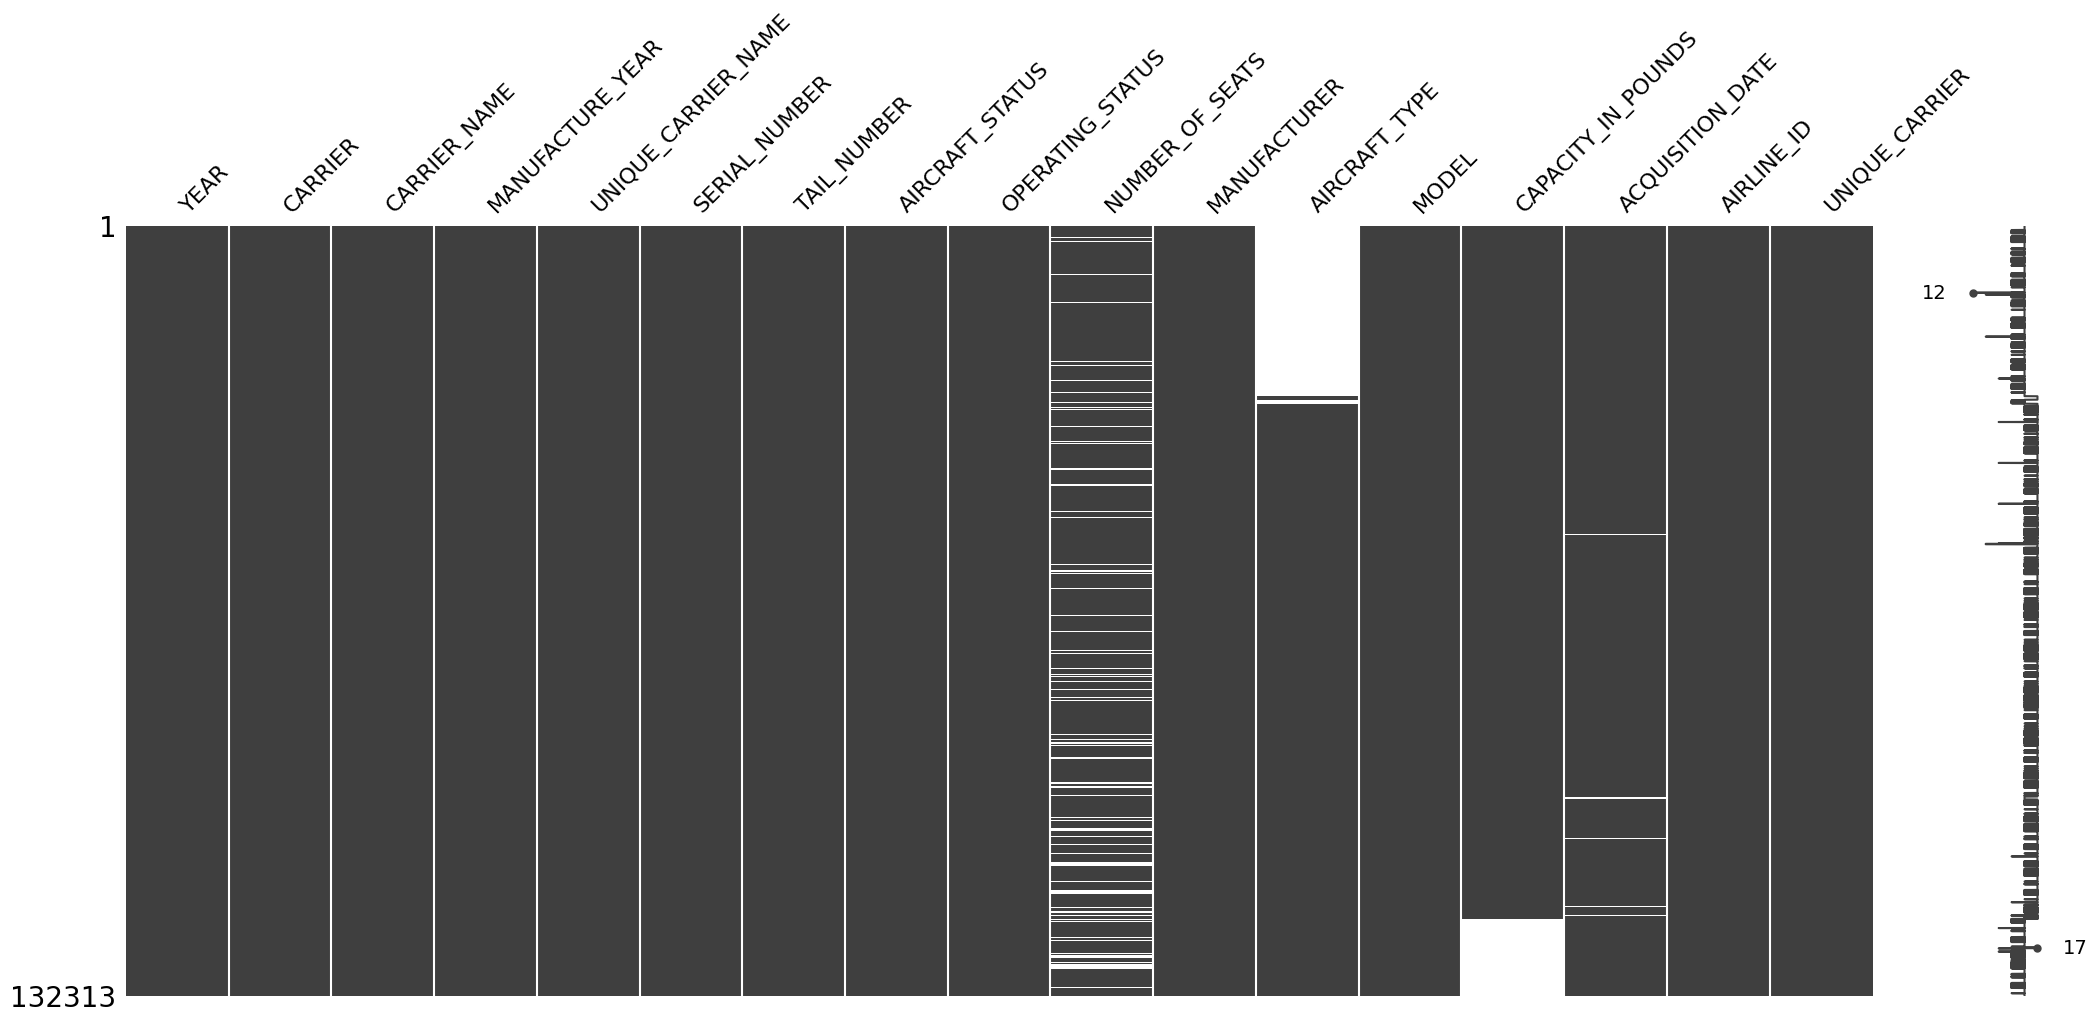

In [3]:
msno.bar(df)
msno.matrix(df)

In [99]:
def simple_imputation(df):
    df = df.copy()
    
    # Fill carrier with Carrier_name. I googled North American Airline's CARRIER code.
    carrier_mask = (
        df["CARRIER_NAME"].eq("North American Airlines") &
        df["CARRIER"].isna()
    )
    df.loc[carrier_mask, "CARRIER"] = "NAA" 
    
    
    # Filling Carrier_name by Carriers OH and L4.
    oh_carrier_name_mask = (df["CARRIER"] == "OH") & (df["CARRIER_NAME"].isna())
    oh_name = df.loc[df["CARRIER"] == "OH", "CARRIER_NAME"].dropna().mode()
    if len(oh_name) > 0:
        df.loc[oh_carrier_name_mask, "CARRIER_NAME"] = oh_name.iloc[0]
    
    l4_carrier_name_mask = (df["CARRIER"] == "L4") & (df["CARRIER_NAME"].isna())
    l4_name = df.loc[df["CARRIER"] == "L4", "CARRIER_NAME"].dropna().mode()
    if len(l4_name) > 0:
        df.loc[l4_carrier_name_mask, "CARRIER_NAME"] = l4_name.iloc[0]
    

    # Helper function to impute median value, fallback is overall column median.
    def median_impute_helper(df, column, group_order):
        for col in group_order:
            df[column] = df[column].fillna(
                df.groupby(col)[column].transform("median")
            )
        
        df[column] = df[column].fillna(df[column].median())
        return df

    # These three imputations start from most specific to least specific.
    df = median_impute_helper(
        df,
        column="MANUFACTURE_YEAR",
        group_order=["TAIL_NUMBER", "MODEL", "MANUFACTURER"]
    )
    
    df = median_impute_helper(
        df,
        column="CAPACITY_IN_POUNDS",
        group_order=["TAIL_NUMBER", "MODEL", "AIRCRAFT_TYPE", "MANUFACTURER"]
    )
    
    df = median_impute_helper(
        df,
        column="NUMBER_OF_SEATS",
        group_order=["TAIL_NUMBER", "MODEL", "AIRCRAFT_TYPE", "MANUFACTURER"]
    )

    return df
    

In [100]:
df = simple_imputation(df)

In [101]:
# This helper function combines different model names into one.
# It also removes whitespace and standardizes capitalization as uppercase.
def standardize_combine(df, column, patterns):
    df[column] = df[column].str.upper().str.strip()
    
    for label, keywords in patterns.items():
        if isinstance(keywords, str):
            keywords = [keywords]
        
        regex = "|".join(keywords)
        df.loc[df[column].str.contains(regex, na=False), column] = label
    
    return df

In [102]:
def data_standardization(df):
    df = df.copy()
    # I manually constructed these patterns based on the most common manufacturers.
    manufacture_patterns = {
        "BOEING": "BOEING",
        "EMBRAER": "EMBRAER",
        "BOMBARDIER": "BOMBARDIER",
        "AIRBUS": "AIRBUS",
        "MCDONNELLDOUGLAS": ["MCDONNELL-DOUGLAS", "MCDONNELDOUGLAS"],
        "DOUGLAS": "DOUGLASAIRCRAFT",
        "SAAB AIRCRAFT": "SAAB",
    }
    df = standardize_combine(df, "MANUFACTURER", manufacture_patterns)

    # I manually constructed this pattern based on my observations of mispellings or variations of the same model.
    model_pattern = {
        "CRJ-200": ["CRJ-200-PSGR", "CRJ200"],
        "B757-2": ["757-200", "B-757-2", "B757-200PAX", "B757-200PASSENGER", "B-757-200", "757-200-PSGR"],
        "C-208B": ["CE-208B", "208B"],
        "A320-232": ["AIRBUSA320-232", "AIRBUSA320-232PAX", "A320-232-PSGR"],
        "A320": ["A320-PSGR", "A320PAX"],
        "A320-211-PSGR": ["A320-211"],
        "A320-212-PSGR": "A320-212",
        "737-700PASSENGERONLY": ["B737-700PAX", "B737-700-psgr", "B737-700Pax", "B-737-700-PSGR", "737-700-PSGR"],
        "EMB-145": ["EMB145", "EMBRAER-145"],
        "EMB-140": ["EMB140"],
        "B-737-7H4": ["737-7H4", "B-737-7H4-PSGR"],
        "B737-823": ["B737-823PASSENGER", "737-823"],
        "B737-800PAX": ["B737-800", "737-800PASSENGERONLY", "B-737-800", "B-737-800-PSGR"],
    }
    df = standardize_combine(df, "MODEL", model_pattern)
    
    df["OPERATING_STATUS"] = df["OPERATING_STATUS"].replace({'y':'Y'})
    df = df[df["OPERATING_STATUS"] != ""]
    df["AIRCRAFT_STATUS"] = df["AIRCRAFT_STATUS"].replace({'A': 'a', 'B': 'b', 'o': 'O', 'L': 'O'})
    return df

In [103]:
df = data_standardization(df)

In [104]:
def feature_engineering(df):
    df = df.copy()

    q1 = df["NUMBER_OF_SEATS"].quantile(0.25)
    q2 = df["NUMBER_OF_SEATS"].quantile(0.50)
    q3 = df["NUMBER_OF_SEATS"].quantile(0.75)

    df["SIZE"] = "XLARGE"
    df.loc[df["NUMBER_OF_SEATS"] < q3, "SIZE"] = "LARGE"
    df.loc[df["NUMBER_OF_SEATS"] < q2, "SIZE"] = "MEDIUM"
    df.loc[df["NUMBER_OF_SEATS"] < q1, "SIZE"] = "SMALL"

    size_order = ["SMALL", "MEDIUM", "LARGE", "XLARGE"]

    operation_proportion = pd.crosstab(df["SIZE"], df["OPERATING_STATUS"], normalize="index")
    operation_proportion = operation_proportion.reindex(size_order)
    
    ax = operation_proportion.plot( kind='barh', stacked=True) 
    ax.legend(bbox_to_anchor=(0.15, -0.06), ncol=2)
    ax.set_title("Operating Status Proportions by Size")

    
    aircraft_proportion = pd.crosstab(df["SIZE"], df["AIRCRAFT_STATUS"], normalize="index")
    aircraft_proportion = aircraft_proportion.reindex(size_order)
    
    ax = aircraft_proportion.plot(kind='barh',stacked=True) 
    ax.legend(bbox_to_anchor=(0.15, -0.06), ncol=2)
    ax.set_title("Aircraft Status Proportions by Size")

    return df
    

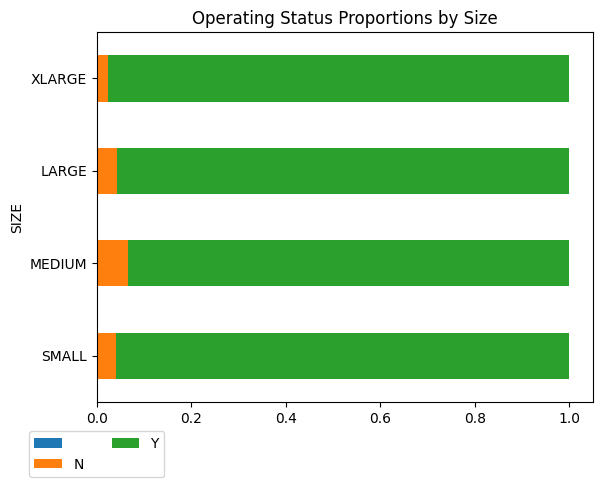

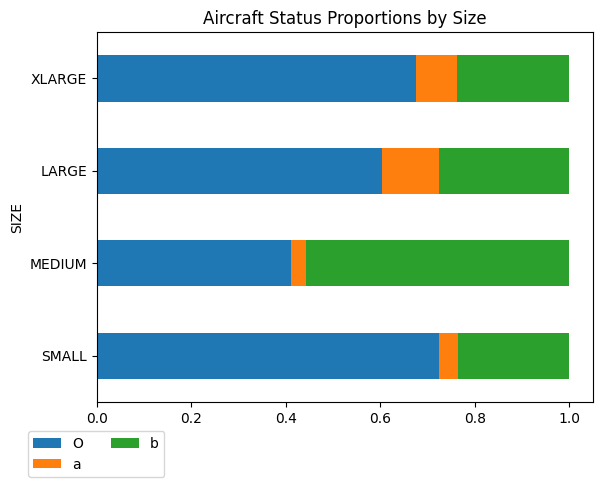

In [105]:
df = feature_engineering(df)

<Axes: >

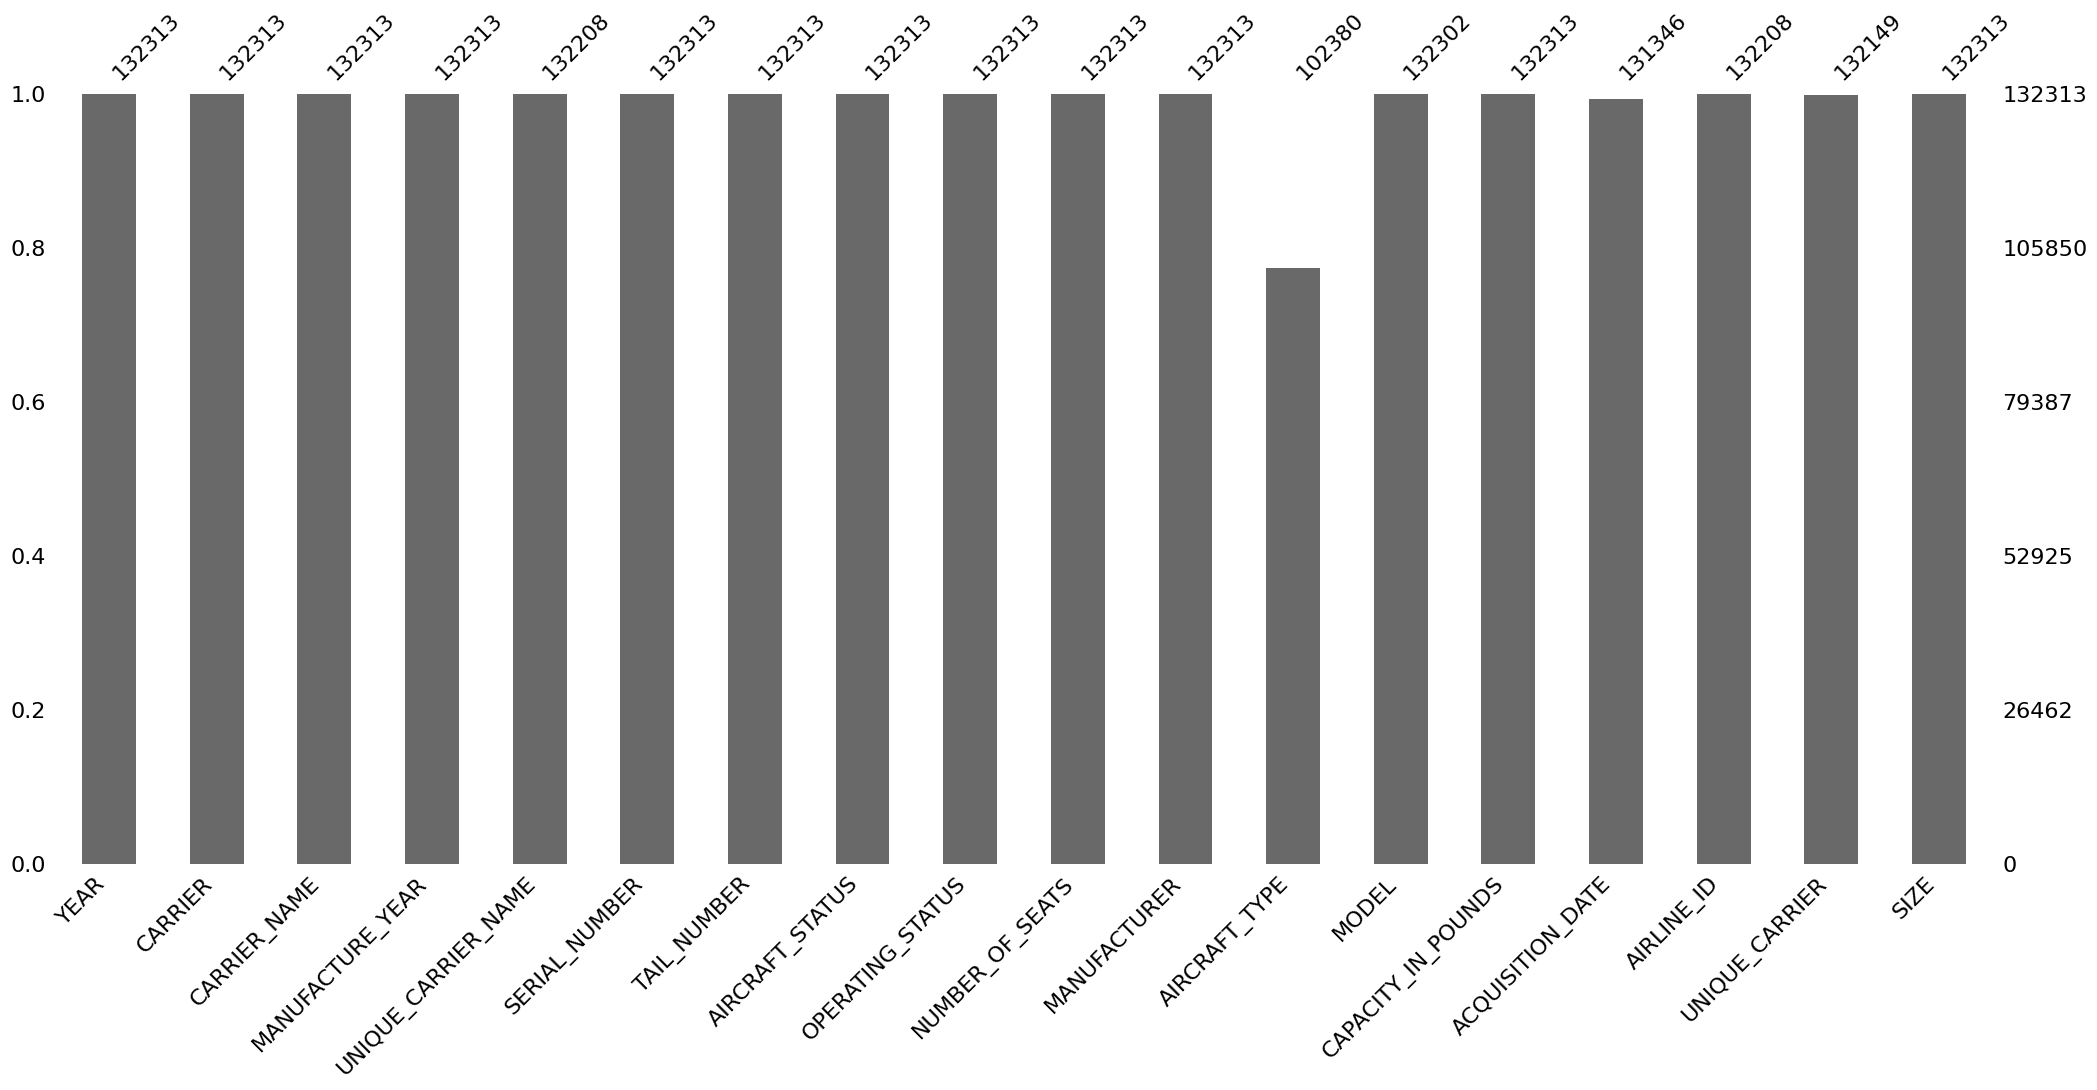

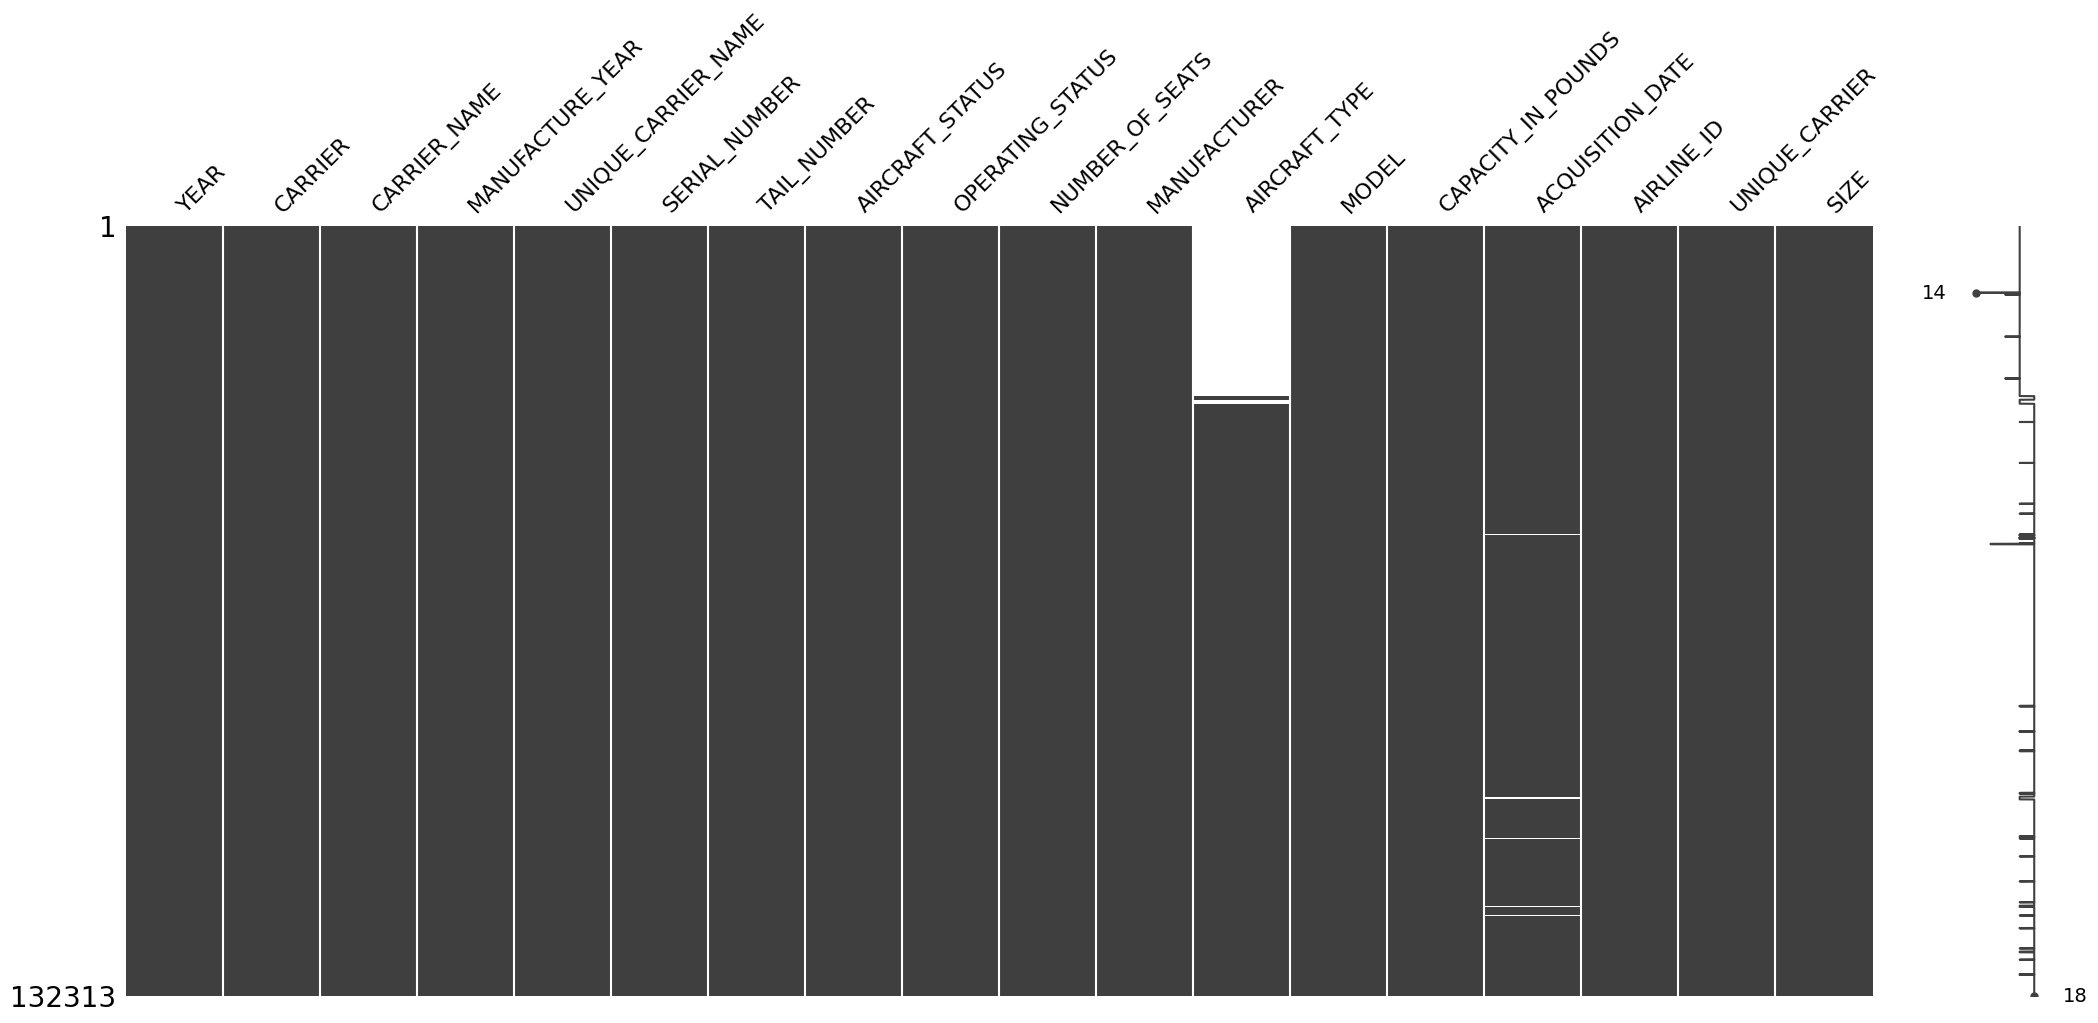

In [30]:
msno.bar(df)
msno.matrix(df)

In [106]:
print("Rows before dropping NA: ", len(df))
df = df.dropna()
print("Rows after dropping NA: ", len(df))

Rows before dropping NA:  132313
Rows after dropping NA:  101276


In [107]:
from scipy import stats

def do_box_cox(cols):
    # Apply Box-Cox
    for col in cols:
        min = df[col].min()
        
        if min <= 0:
            shifted = df[col] - min + 1
        else:
            shifted = df[col]
            
        moved, _ = boxcox(shifted)
        df.loc[shifted.index, f"{col}_BOXCOX"] = moved
        
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    
    for i, col in enumerate(cols):
        new_col = f"{col}_BOXCOX"
    
        # I put original histogram above box-cox histogram so x-axis would line up.
        axes[0, i].hist(df[col], bins=30)
        axes[0, i].set_title(f"Original: {col}")
        axes[0, i].set_xlabel(col)
        axes[0, i].set_ylabel("Count")
        axes[0, i].text(
            0.95, 0.95,
            f"skew={skew(df[col]):.2f}",
            transform=axes[0, i].transAxes,
            ha='right', va='top'
        )
    
        # Box-Cox on bottom row
        axes[1, i].hist(df[new_col], bins=30)
        axes[1, i].set_title(f"Box-Cox: {new_col}")
        axes[1, i].set_xlabel(new_col)
        axes[1, i].set_ylabel("Count")
        axes[1, i].text(
            0.95, 0.95,
            f"skew={skew(df[new_col]):.2f}",
            transform=axes[1, i].transAxes,
            ha='right', va='top'
        )
    
    plt.tight_layout()
    plt.show()

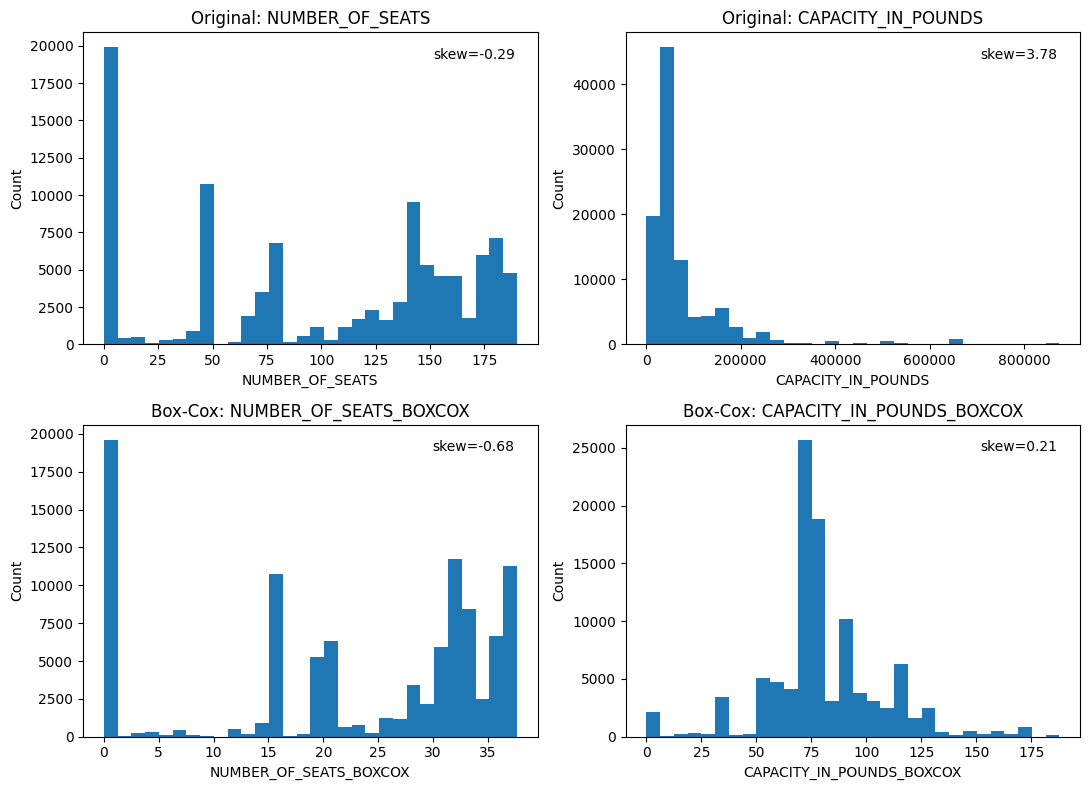

In [108]:
cols = ["NUMBER_OF_SEATS", "CAPACITY_IN_POUNDS"]
do_box_cox(cols)

In [110]:
df.isna().any(axis=1).sum()

np.int64(0)

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from scipy.special import inv_boxcox

def run_models(df):
    _, lambda_seats = boxcox(df["NUMBER_OF_SEATS"] - df["NUMBER_OF_SEATS"].min() + 1)
    _, lambda_cap   = boxcox(df["CAPACITY_IN_POUNDS"] - df["CAPACITY_IN_POUNDS"].min() + 1)

    cat_cols = ["CARRIER", "UNIQUE_CARRIER", "AIRCRAFT_STATUS",
                "OPERATING_STATUS", "MANUFACTURER", "AIRCRAFT_TYPE", "MODEL"]
    df_copy = df.copy()
    for col in cat_cols:
        df_copy[col] = LabelEncoder().fit_transform(df_copy[col].astype(str))

    # Drop redundant (CARRIER) or useless (SERIAL_NUMBER) columns.
    drop_cols = ["NUMBER_OF_SEATS", "CAPACITY_IN_POUNDS", "NUMBER_OF_SEATS_BOXCOX",
                 "CAPACITY_IN_POUNDS_BOXCOX", "SERIAL_NUMBER", "TAIL_NUMBER",
                 "ACQUISITION_DATE", "AIRLINE_ID", "CARRIER_NAME", "UNIQUE_CARRIER_NAME", "SIZE"]
    feature_cols = [c for c in df_copy.columns if c not in drop_cols]

    X = df_copy[feature_cols]
    X_train, X_test, \
    y_seats_train, y_seats_test, \
    y_cap_train,   y_cap_test = train_test_split(
        X,
        df["NUMBER_OF_SEATS_BOXCOX"],
        df["CAPACITY_IN_POUNDS_BOXCOX"],
        test_size=0.2, random_state=42
    )

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }

    for target_name, y_train, y_test, lmbda, orig in [
        ("NUMBER_OF_SEATS",    y_seats_train, y_seats_test, lambda_seats, df["NUMBER_OF_SEATS"]),
        ("CAPACITY_IN_POUNDS", y_cap_train,   y_cap_test,   lambda_cap,   df["CAPACITY_IN_POUNDS"])
    ]:
        for model_name, model in models.items():
            model.fit(X_train, y_train)
            train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
            test_rmse  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test)))
            print(f"{model_name} predicting {target_name}")
            print(f"Train RMSE: {train_rmse:.4f}")
            print(f"Test  RMSE: {test_rmse:.4f}\n")

run_models(df)

Linear Regression predicting NUMBER_OF_SEATS
Train RMSE: 12.4191
Test  RMSE: 12.4737

Random Forest predicting NUMBER_OF_SEATS
Train RMSE: 0.7074
Test  RMSE: 1.0332

Linear Regression predicting CAPACITY_IN_POUNDS
Train RMSE: 24.8251
Test  RMSE: 24.8450

Random Forest predicting CAPACITY_IN_POUNDS
Train RMSE: 1.4737
Test  RMSE: 2.6103

